In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
seed = 123
g = torch.Generator().manual_seed(seed)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        break

In [ ]:
#Import deep learning libraries

import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split, Subset, Dataset
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np
from PIL import Image
import time
from tqdm import tqdm


In [ ]:
# Define the transformations
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # Convert to grayscale
    transforms.Resize((150, 150)),                # Resize images to 150x150
    transforms.ToTensor(),                        # Convert images to tensors
    transforms.Normalize(mean=[0.5], std=[0.5])   # Normalize images to [0, 1]
])

In [ ]:
#train dataset
train_path = '/kaggle/input/intel-image-classification/seg_train/seg_train'
train_dataset = datasets.ImageFolder(root=train_path, transform=transform)
# Define batch size
batch_size = 32
# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Example: Iterate over the first batch
for images, labels in train_loader:
    print(images.shape, labels.shape)
    break

In [ ]:
#Validation and test data
val_path = '/kaggle/input/intel-image-classification/seg_test/seg_test'
val_dataset_full = datasets.ImageFolder(root=val_path, transform=transform)

targets = np.array(val_dataset_full.targets)  # Labels for stratification
sample_size = 100  # Total sample size

num_iterations = 2  # Number of different samples you want
# Create stratified split with multiple iterations
splitter = StratifiedShuffleSplit(n_splits=num_iterations, test_size=sample_size, random_state=42)

sample_datasets = []
for train_idx, sample_idx in splitter.split(np.zeros(len(targets)), targets):
    sample_datasets.append(Subset(val_dataset_full, sample_idx))

val_dataset = sample_datasets[0]
test_dataset = sample_datasets[1]

# Define batch size
batch_size = 100
# Create DataLoaders
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [ ]:
# Step 1: List the images in the directory
image_directory = '/kaggle/input/intel-image-classification/seg_pred/seg_pred'
image_files = os.listdir(image_directory)

# Filter out only files with image extensions if necessary
image_files = [f for f in image_files if f.endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]

# Step 2: Select the first 200 images
image_files = image_files[:200]

class SelectedFilesDataset(Dataset):
    def __init__(self, root_dir, file_names, transform=None):
        """
        Args:
            root_dir (str): Directory where files are stored.
            file_names (list): List of selected filenames (not full paths).
            transform (callable, optional): Transformations to apply to images.
        """
        self.root_dir = root_dir
        self.file_names = file_names
        self.transform = transform

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, idx):
        file_path = os.path.join(self.root_dir, self.file_names[idx])
        image = Image.open(file_path).convert("RGB")  # Load image

        if self.transform:
            image = self.transform(image)

        return image, self.file_names[idx]  # Return image + filename

# Example usage

comp_test_dataset = SelectedFilesDataset(image_directory, image_files, transform = transform)
comp_test_loader = DataLoader(comp_test_dataset, batch_size=100, shuffle=False)

In [ ]:
# minitorch.py
import torch
import matplotlib.pyplot as plt

class Net:
    def __init__(self): 
        self.layers = []
        self.training = True
        
    def add(self, layer): 
        self.layers.append(layer)
        
    def train(self): 
        self.training = True
        for l in self.layers:
            if hasattr(l, 'train'): l.train()
        return self
        
    def eval(self):  
        self.training = False
        for l in self.layers:
            if hasattr(l, 'eval'): l.eval()
        return self
        
    def forward(self, X):
        for layer in self.layers: 
            X = layer.forward(X)
        return X
        
    def backward(self, dZ):
        for layer in reversed(self.layers): 
            dZ = layer.backward(dZ)
        return dZ
        
    def update(self, lr):
        for layer in self.layers:
            if hasattr(layer, "update"): 
                layer.update(lr)

class Linear:
    def __init__(self, nin, nout, device="cpu"):
        # He initialization is better for ReLU networks
        self.W = torch.randn(nin, nout, device=device) * torch.sqrt(torch.tensor(2.0/nin))
        self.b = torch.zeros(nout, device=device)
        self.device = device

    def forward(self, X):
        self.X = X
        return torch.matmul(X, self.W) + self.b

    def backward(self, dZ):
        self.dW = torch.matmul(self.X.t(), dZ)
        self.db = torch.sum(dZ, dim=0)
        return torch.matmul(dZ, self.W.t())

    def update(self, lr):
        self.W -= lr * self.dW
        self.b -= lr * self.db

class ReLU:
    def forward(self, Z):
        self.Z = Z
        return torch.clamp(Z, min=0)

    def backward(self, dA):
        dZ = dA.clone()
        dZ[self.Z <= 0] = 0
        return dZ

class BatchNorm1D:
    def __init__(self, n_features, eps=1e-5, momentum=0.1, device="cpu"):
        self.eps, self.momentum, self.device = eps, momentum, device
        self.gamma = torch.ones(n_features, device=device)
        self.beta = torch.zeros(n_features, device=device)
        self.running_mean = torch.zeros(n_features, device=device)
        self.running_var = torch.ones(n_features, device=device)
        self.training = True

    def train(self): self.training = True; return self
    def eval(self): self.training = False; return self

    def forward(self, X):
        if self.training:
            self.batch_mean = X.mean(dim=0)
            self.batch_var = X.var(dim=0, unbiased=False)
            self.std = torch.sqrt(self.batch_var + self.eps)
            self.X_hat = (X - self.batch_mean) / self.std
            self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * self.batch_mean
            self.running_var = (1 - self.momentum) * self.running_var + self.momentum * self.batch_var
        else:
            self.std = torch.sqrt(self.running_var + self.eps)
            self.X_hat = (X - self.running_mean) / self.std
        
        self.X = X
        return self.gamma * self.X_hat + self.beta

    def backward(self, dY):
        m = dY.size(0)
        self.dbeta = dY.sum(dim=0)
        self.dgamma = (dY * self.X_hat).sum(dim=0)
        dx_hat = dY * self.gamma
        x_mu = self.X - self.batch_mean
        invstd = 1.0 / self.std
        dvar = torch.sum(dx_hat * x_mu * -0.5 * (invstd**3), dim=0)
        dmean = torch.sum(-dx_hat * invstd, dim=0) + dvar * torch.mean(-2.0 * x_mu, dim=0)
        return dx_hat * invstd + (2.0/m) * x_mu * dvar + dmean/m

    def update(self, lr):
        self.gamma -= lr * self.dgamma
        self.beta -= lr * self.dbeta

class Dropout:
    def __init__(self, p=0.5, device="cpu"):
        self.p, self.device, self.training = p, device, True

    def train(self): self.training = True; return self
    def eval(self): self.training = False; return self

    def forward(self, X):
        if self.training and self.p > 0:
            keep_prob = 1 - self.p
            self.mask = (torch.rand(X.shape, device=self.device) < keep_prob).float() / keep_prob
            return X * self.mask
        self.mask = torch.ones_like(X)
        return X

    def backward(self, dY):
        return dY * self.mask

class CrossEntropyFromLogits:
    def forward(self, Z, Y):
        self.Y = Y
        Z_stable = Z - Z.max(dim=1, keepdim=True).values
        expZ = torch.exp(Z_stable)
        self.A = expZ / expZ.sum(dim=1, keepdim=True)
        log_probs = Z_stable - torch.log(expZ.sum(dim=1, keepdim=True))
        correct_log_probs = log_probs[torch.arange(Z.shape[0]), Y]
        return -correct_log_probs.mean()

    def backward(self, n_classes):
        m = self.Y.shape[0]
        Y_one_hot = torch.zeros(m, n_classes, device=self.A.device)
        Y_one_hot[torch.arange(m), self.Y] = 1.0
        return (self.A - Y_one_hot) / m
    

def train_model(net, train_loader, val_loader, criterion, epochs=10, lr=0.1):
    history = {
        "train_loss": [], "train_acc": [], 
        "val_loss": [], "val_acc": []
    }
    batch_losses = []
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    for epoch in range(epochs):
        net.train()
        epoch_loss = 0
        correct_train = 0
        total_train = 0
        
        for X, y in train_loader:
            X = X.view(X.shape[0], -1).to(device)
            y = y.to(device)
            
            outputs = net.forward(X)
            loss = criterion.forward(outputs, y)
            batch_losses.append(loss.item())
            
            dZ = criterion.backward(n_classes=6)
            net.backward(dZ)
            net.update(lr)
            
            epoch_loss += loss.item()
            
            # --- Added: Calculate Training Accuracy ---
            preds = torch.argmax(outputs, dim=1)
            correct_train += (preds == y).sum().item()
            total_train += y.size(0)
            
        # Validation
        net.eval()
        correct_val, total_val, val_loss = 0, 0, 0
        for X, y in val_loader:
            X = X.view(X.shape[0], -1).to(device)
            y = y.to(device)
            outputs = net.forward(X)
            val_loss += criterion.forward(outputs, y).item()
            preds = torch.argmax(outputs, dim=1)
            correct_val += (preds == y).sum().item()
            total_val += y.size(0)
            
        # Store all metrics
        history["train_loss"].append(epoch_loss / len(train_loader))
        history["train_acc"].append(correct_train / total_train)
        history["val_loss"].append(val_loss / len(val_loader))
        history["val_acc"].append(correct_val / total_val)
        
        print(f"Epoch {epoch+1}/{epochs} | Train Acc: {history['train_acc'][-1]:.4f} | Val Acc: {history['val_acc'][-1]:.4f}")
        
    return history, batch_losses

def plot_history(history, title=""):
    import matplotlib.pyplot as plt
    epochs = range(1, len(history["train_loss"]) + 1)

    # Plot Loss
    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["train_loss"], 'r-o', label="train")
    plt.plot(epochs, history["val_loss"], 'orange', linestyle='--', label="val")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(f"Loss {title}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Plot Accuracy
    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["train_acc"], 'b-s', label="train")
    plt.plot(epochs, history["val_acc"], 'cyan', linestyle='--', label="val")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(f"Accuracy {title}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_per_batch_loss(batch_losses, title="Per-batch loss"):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 4))
    plt.plot(batch_losses, color='gray', alpha=0.4, label='Batch Loss')
    
    # Add trend line
    if len(batch_losses) > 50:
        import numpy as np
        window = 50
        weights = np.ones(window) / window
        trend = np.convolve(batch_losses, weights, mode='valid')
        plt.plot(range(window-1, len(batch_losses)), trend, 'r', label='Trend')

    plt.xlabel('Batch Step')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.show()

In [ ]:
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split

# Device configuration
device = 'cuda' if torch.cuda.is_available() else 'cpu'

seed = 123
g = torch.Generator().manual_seed(seed)

# Transform
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Loading Intel Image Dataset paths
train_path = '/kaggle/input/intel-image-classification/seg_train/seg_train'
full_trainset = datasets.ImageFolder(root=train_path, transform=transform)

# Split 80/20
train_size = int(0.8 * len(full_trainset))
val_size = len(full_trainset) - train_size
trainset, valset = random_split(full_trainset, [train_size, val_size])

train_loader = DataLoader(trainset, batch_size=32, shuffle=True)
val_loader = DataLoader(valset, batch_size=32, shuffle=False)

criterion = CrossEntropyFromLogits()

# Definición de arquitecturas

In [ ]:
# Architecture D
net_D = Net()

# Layer 1
net_D.add(Linear(22500, 1024, device=device))
net_D.add(BatchNorm1D(1024, device=device))
net_D.add(ReLU())
net_D.add(Dropout(p=0.4, device=device))

# Layer 2
net_D.add(Linear(1024, 256, device=device))
net_D.add(BatchNorm1D(256, device=device))
net_D.add(ReLU())
net_D.add(Dropout(p=0.3, device=device))

# Layer 3
net_D.add(Linear(256, 64, device=device))
net_D.add(BatchNorm1D(64, device=device))
net_D.add(ReLU())


# Output Layer
net_D.add(Linear(64, 6, device=device))

In [ ]:
# Architecture E
net_E = Net()

# Layer 1
net_E.add(Linear(22500, 2048, device=device))
net_E.add(BatchNorm1D(2048, device=device))
net_E.add(ReLU())
# Layer 2
net_E.add(Dropout(p=0.6, device=device)) 

# Output Layer
net_E.add(Linear(2048, 6, device=device))

In [33]:
# Architecture F
net_F = Net()

# Layer 1
net_F.add(Linear(22500, 512, device=device)) 
net_F.add(BatchNorm1D(512, device=device))
net_F.add(ReLU())
net_F.add(Dropout(p=0.3, device=device))

# Layer 2
net_F.add(Linear(512, 256, device=device))
net_F.add(BatchNorm1D(256, device=device))
net_F.add(ReLU())

# Output layer
net_F.add(Linear(256, 6, device=device))

# Training and Plotting

Training Arch D
Epoch 1/10 | Train Acc: 0.8578 | Val Acc: 0.4952
Epoch 2/10 | Train Acc: 0.8550 | Val Acc: 0.4984
Epoch 3/10 | Train Acc: 0.8647 | Val Acc: 0.5098
Epoch 4/10 | Train Acc: 0.8614 | Val Acc: 0.4827
Epoch 5/10 | Train Acc: 0.8738 | Val Acc: 0.4792
Epoch 6/10 | Train Acc: 0.8725 | Val Acc: 0.4938
Epoch 7/10 | Train Acc: 0.8809 | Val Acc: 0.5037
Epoch 8/10 | Train Acc: 0.8889 | Val Acc: 0.4809
Epoch 9/10 | Train Acc: 0.8837 | Val Acc: 0.4564
Epoch 10/10 | Train Acc: 0.8949 | Val Acc: 0.5016


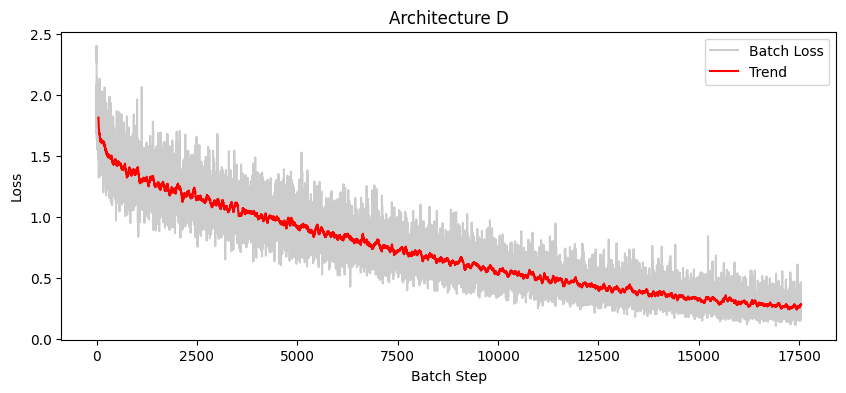

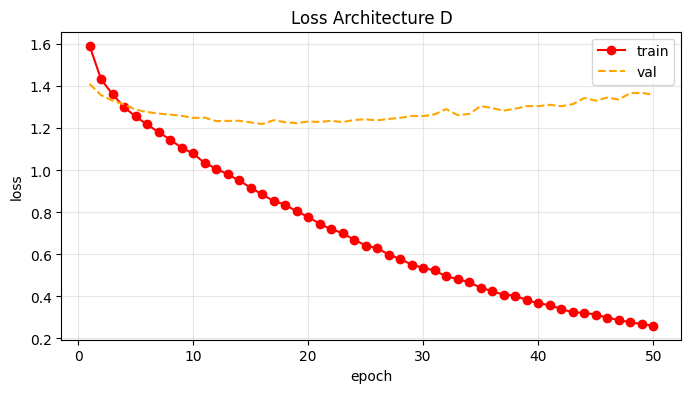

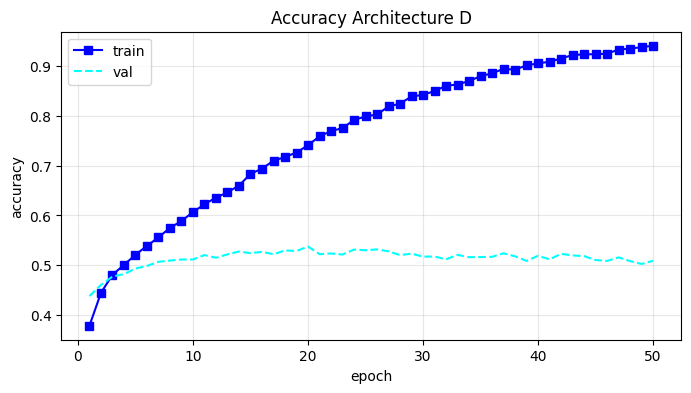


Training Arch E
Epoch 1/10 | Train Acc: 0.6992 | Val Acc: 0.5102
Epoch 2/10 | Train Acc: 0.7167 | Val Acc: 0.5287
Epoch 3/10 | Train Acc: 0.7234 | Val Acc: 0.5240
Epoch 4/10 | Train Acc: 0.7371 | Val Acc: 0.5144
Epoch 5/10 | Train Acc: 0.7575 | Val Acc: 0.5098
Epoch 6/10 | Train Acc: 0.7665 | Val Acc: 0.5244
Epoch 7/10 | Train Acc: 0.7726 | Val Acc: 0.5030
Epoch 8/10 | Train Acc: 0.7722 | Val Acc: 0.5080
Epoch 9/10 | Train Acc: 0.7875 | Val Acc: 0.5244
Epoch 10/10 | Train Acc: 0.7984 | Val Acc: 0.5226


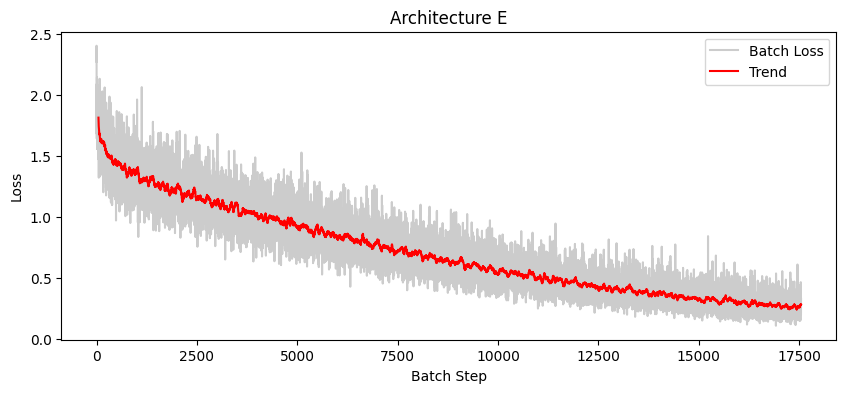

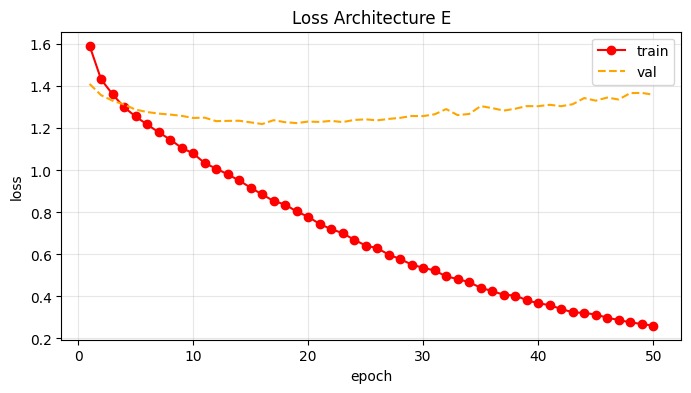

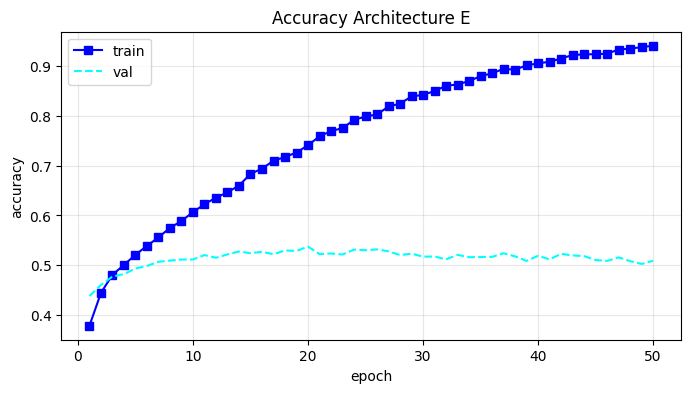


Training Arch F
Epoch 1/10 | Train Acc: 0.8361 | Val Acc: 0.5009
Epoch 2/10 | Train Acc: 0.8413 | Val Acc: 0.4881
Epoch 3/10 | Train Acc: 0.8509 | Val Acc: 0.4955
Epoch 4/10 | Train Acc: 0.8711 | Val Acc: 0.4995
Epoch 5/10 | Train Acc: 0.8777 | Val Acc: 0.4710
Epoch 6/10 | Train Acc: 0.8782 | Val Acc: 0.4913
Epoch 7/10 | Train Acc: 0.8847 | Val Acc: 0.4838
Epoch 8/10 | Train Acc: 0.9023 | Val Acc: 0.4941
Epoch 9/10 | Train Acc: 0.9013 | Val Acc: 0.4948
Epoch 10/10 | Train Acc: 0.9076 | Val Acc: 0.4866


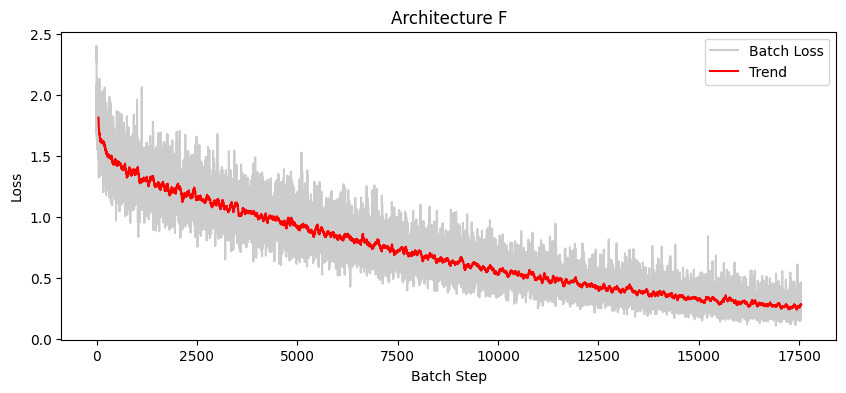

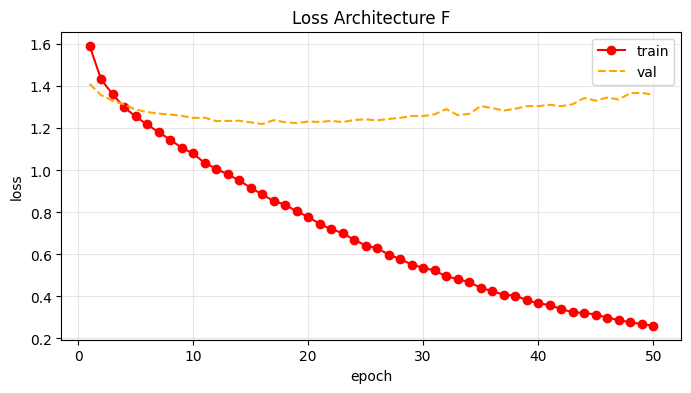

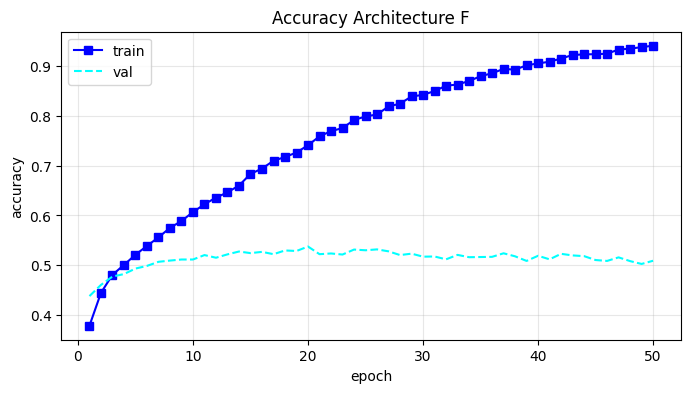

In [32]:
# Training Architecture D
print("Training Arch D")
history_d, batch_losses_d = train_model(
    net=net_D, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    criterion=criterion, 
    epochs=10, 
    lr=0.1
)

plot_per_batch_loss(batch_losses, title="Architecture D")
plot_history(history, title="Architecture D")

# Training Architecture E
print("\nTraining Arch E")
history_e, batch_losses_e = train_model(
    net=net_E, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    criterion=criterion, 
    epochs=10, 
    lr=0.1
)
plot_per_batch_loss(batch_losses, title="Architecture E")
plot_history(history, title="Architecture E")

# Training Architecture F
print("\nTraining Arch F")
history_f, batch_losses_d = train_model(
    net=net_F, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    criterion=criterion, 
    epochs=10, 
    lr=0.1
)
plot_per_batch_loss(batch_losses, title="Architecture F")
plot_history(history, title="Architecture F")

Training Arch D
Epoch 1/10 | Train Acc: 0.8987 | Val Acc: 0.5112
Epoch 2/10 | Train Acc: 0.9018 | Val Acc: 0.5191
Epoch 3/10 | Train Acc: 0.9018 | Val Acc: 0.5112
Epoch 4/10 | Train Acc: 0.9041 | Val Acc: 0.4884
Epoch 5/10 | Train Acc: 0.9113 | Val Acc: 0.5151
Epoch 6/10 | Train Acc: 0.9130 | Val Acc: 0.5005
Epoch 7/10 | Train Acc: 0.9118 | Val Acc: 0.5012
Epoch 8/10 | Train Acc: 0.9182 | Val Acc: 0.5023
Epoch 9/10 | Train Acc: 0.9181 | Val Acc: 0.4977
Epoch 10/10 | Train Acc: 0.9266 | Val Acc: 0.4874


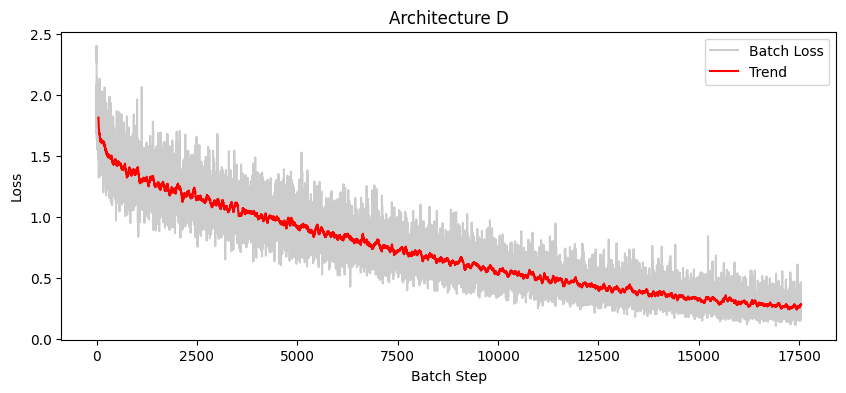

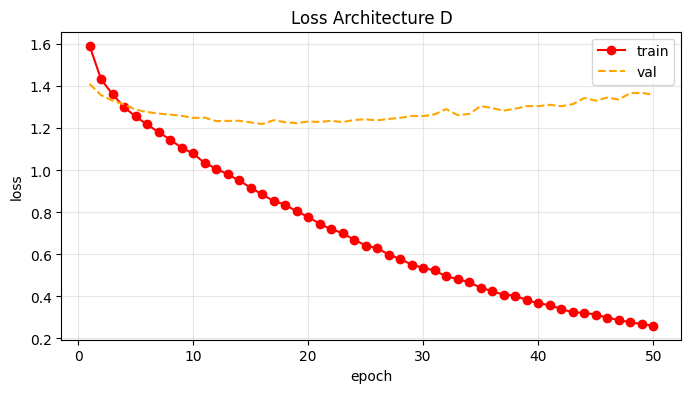

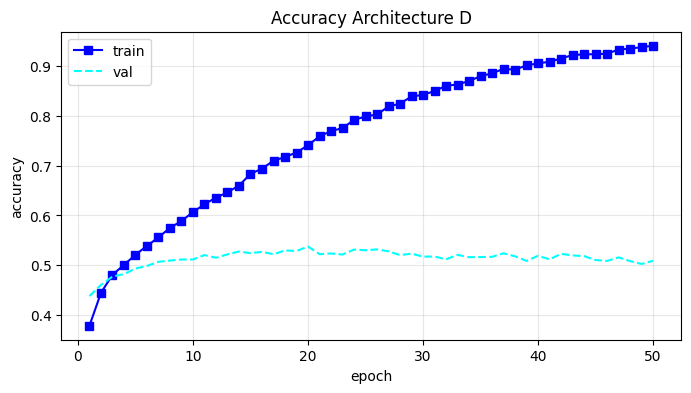

In [35]:
# Training Architecture D
print("Training Arch D")
history_f, batch_losses_d = train_model(
    net=net_D, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    criterion=criterion, 
    epochs=10, 
    lr=0.1
)

plot_per_batch_loss(batch_losses, title="Architecture D")
plot_history(history, title="Architecture D")


### Summary of Architectures Tried (Intel Image Dataset)

| Architecture | Best Val Accuracy | Overfitting Gap (Train - Val) | Comments |
| :--- | :--- | :--- | :--- |
| **D (1024→256→64→6)** | ~50.98% (Ep 3) | ~39.3% (89.5% vs 50.2%) | Severe overfitting. The deep network quickly memorized the training images but failed to generalize. |
| **E (2048→6)** | **~52.87%** (Ep 2) | **~27.5%** (79.8% vs 52.3%) | Best validation accuracy and lowest overfitting gap. The aggressive Dropout (0.6) prevented the massive layer from memorizing instantly. |
| **F (512→256→6)** | ~50.09% (Ep 1) | ~42.1% (90.7% vs 48.6%) | Worst generalization. Validation accuracy peaked at Epoch 1 and then steadily declined while training accuracy climbed. |

### Evaluation & Insights

**What helped:**
* **Aggressive Dropout:** Architecture E utilized a massive single hidden layer (2048 neurons) but applied heavy regularization (Dropout p=0.6). This combination yielded the best validation accuracy and the smallest gap between training and validation, proving that strong regularization is mandatory for this dataset.

**Why the models struggled to generalize:**
* **Spatial Information Loss:** Flattening 150x150 images into 1D vectors of 22,500 features destroys spatial relationships. A standard MLP struggles to recognize complex objects (like a mountain or a street) when pixels are treated independently, which is why all models capped around ~50-52% validation accuracy despite reaching ~90% training accuracy. 
* **Learning Rate (0.1):** The validation accuracy fluctuated heavily across all runs. A learning rate of 0.1 is likely too high for the complex loss landscape of 22,500 input features, causing the optimizer to bounce around the minimum rather than settling into it.

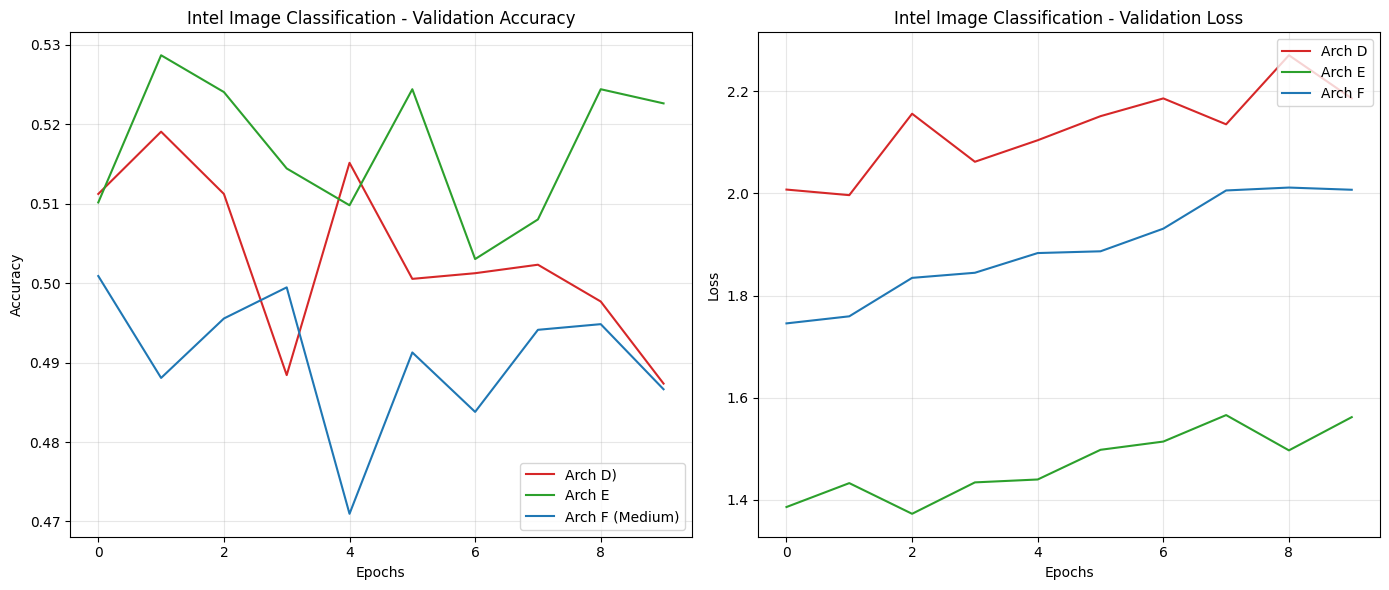

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Accuracy Subplot
plt.subplot(1, 2, 1)
plt.plot(history_d['val_acc'], label='Arch D)', color='tab:red')
plt.plot(history_e['val_acc'], label='Arch E', color='tab:green')
plt.plot(history_f['val_acc'], label='Arch F (Medium)', color='tab:blue') 
plt.title("Intel Image Classification - Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# Loss Subplot
plt.subplot(1, 2, 2)
plt.plot(history_d['val_loss'], label='Arch D', color='tab:red')
plt.plot(history_e['val_loss'], label='Arch E', color='tab:green')
plt.plot(history_f['val_loss'], label='Arch F', color='tab:blue')
plt.title("Intel Image Classification - Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [39]:
import pandas as pd
import torch

# 1. Set your best model to evaluation mode
net_E.eval()
preds = []
ids = []

# 2. Iterate through the competition test data
with torch.no_grad():
    for images, names in comp_test_loader:
        # Flatten the 150x150 images to 22,500 features
        X_flat = images.view(images.shape[0], -1).to(device)
        
        # Forward pass
        Z = net_E.forward(X_flat)
        
        # Get the highest probability class
        _, predicted = torch.max(Z, 1)
        
        preds.extend(predicted.cpu().numpy().tolist())
        
        # Handle the names depending on whether they are tensors or tuples of strings
        if isinstance(names, torch.Tensor):
            ids.extend(names.tolist())
        else:
            ids.extend(names)

# 3. Create the DataFrame and save to CSV
df_submission = pd.DataFrame({
    'id': ids,
    'pred': preds
})

df_submission.to_csv('predictions.csv', index=False)